In [4]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler

In [5]:
penguins_df = sns.load_dataset("penguins")

In [6]:
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [7]:
penguins_df.dropna(inplace=True)

In [8]:
penguins_df.drop(columns=['species', 'island'], inplace=True)

In [9]:
X = penguins_df.drop(columns=['sex'])
y = penguins_df['sex']

In [10]:
y = pd.get_dummies(y, drop_first=True, dtype=int)

In [11]:
y

,Male
0,1
1,0
2,0
4,0
5,1
...,...
338,0
340,0
341,1
342,0


## Train test split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.20)

## Scaling

In [49]:
scaler = MinMaxScaler()

In [50]:
scaler.fit(X_train)

MinMaxScaler()

In [54]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
X_train_scaled

array([[0.32      , 0.07142857, 0.71186441, 0.54166667],
       [0.18909091, 0.55952381, 0.3220339 , 0.18055556],
       [0.65090909, 0.33333333, 0.88135593, 0.73611111],
       ...,
       [0.27636364, 0.54761905, 0.3559322 , 0.13888889],
       [0.48727273, 0.22619048, 0.81355932, 0.63888889],
       [0.21818182, 0.46428571, 0.15254237, 0.13194444]])

## Create and train model

In [58]:
knn = KNeighborsClassifier()

In [60]:
knn.fit(X_train_scaled, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

## Use model

In [73]:
random_penguin = X_test.sample()

In [74]:
random_penguin_scaled = scaler.transform(random_penguin)

In [87]:
random_penguin

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
82,36.7,18.8,187.0,3800.0


In [88]:
y_test.loc[82]

Male    0
Name: 82, dtype: int64

In [85]:
knn.predict(random_penguin_scaled)

array([0])

In [80]:
knn.score(X_test_scaled, y_test)

0.8805970149253731

### Using KNRegressor, predict mass of the penguin based on the bill_length, bill_depth, and flipper_length

In [90]:
penguins_df.drop(columns=['sex'], inplace=True)
X = penguins_df.drop(columns=['body_mass_g'])
y = penguins_df['body_mass_g']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.20)

In [92]:
scaler = MinMaxScaler()
scaler.fit(X_train)

MinMaxScaler()

In [93]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [95]:
knn = KNeighborsRegressor()

In [96]:
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [97]:
random_penguin = X_test.sample()

In [98]:
random_penguin

,bill_length_mm,bill_depth_mm,flipper_length_mm
217,49.6,18.2,193.0


In [99]:
random_penguin_scaled = scaler.transform(random_penguin)

In [100]:
y_test.loc[217]

3775.0

In [101]:
knn.predict(random_penguin_scaled)

array([3725.])

In [102]:
knn.score(X_test_scaled, y_test)

0.8444573205313124

## Decision Tree

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [17]:
dt = DecisionTreeClassifier(max_depth = 3)

In [18]:
X = penguins_df.select_dtypes('number')
y = penguins_df['sex']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.20)

In [20]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [27]:
import matplotlib.pyplot as plt

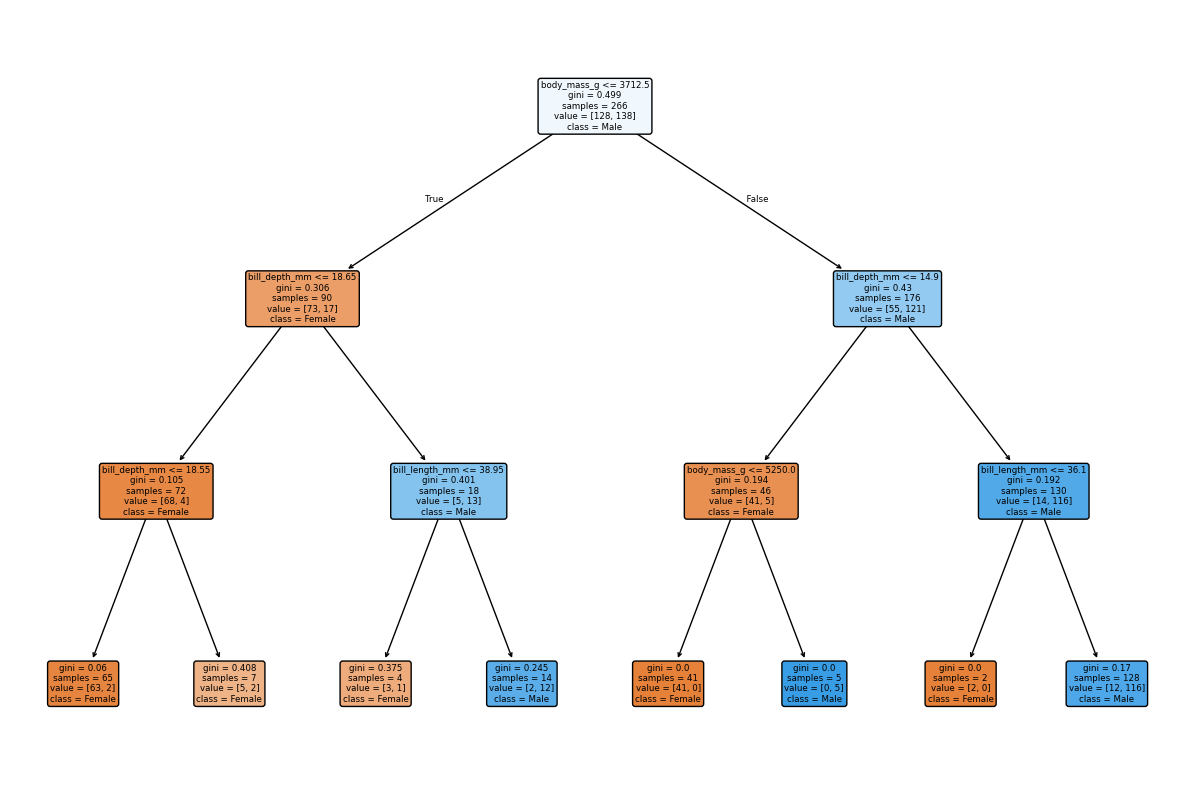

In [28]:
plt.figure(figsize=(12,8))
plot_tree(
    dt,
    feature_names = X_train.columns,
    class_names = y_train.unique(),
    filled=True,
    rounded=True,
    impurity=True,
)
plt.tight_layout()
plt.show()

In [29]:
dt.score(X_test, y_test)

0.835820895522388